# **Model Compression - XGBoost**

**Structure of the notebook:**

**Step 1 - Load saved model (xgboost_final_model.joblib) + test data**

**Step 2 - Baseline reference (RE-MEASURE uncompressed model's size/latency/accuracy)**

**Step 3 - Compression Technique 1: Tree/estimator reduction**

**Step 4 - Evaluate Technique 1**

**Step 5 - Compression Technique 2: Precision reduction**

**Step 6 - Evaluate Technique 2**

**Step 7 - Combination: Tree reduction + precision reduction together**

**Step 8 - Evaluate Combination**

**Step 9 - Summary comparison (Baseline vs Technique 1 vs Technique 2 vs Combination)**

**Step 10 - Save final compressed model(s) + summary results**

(Remark: Source files are from previous XGBoost Modelling outputs.

Files are stored in github: https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main)






In [1]:
# Read the split data and trained XGBoost model directly from GitHub (public repo, no auth needed);
# save this notebook's own outputs (figures, compressed models, summary) to a local Colab folder.
import os
import pandas as pd
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/paulmcchan/Surrey-AI-and-Sustainability/main"
PROCESSED_DIR = f"{BASE_URL}/data/processed"       # read: split datasets from the EDA notebook
MODEL_DIR = f"{BASE_URL}/outputs/xgboost"          # read: trained model from the XGBoost modelling notebook

OUTPUT_DIR = "outputs/xgboost_compression"          # write: this notebook's own figures, models, summary
os.makedirs(OUTPUT_DIR, exist_ok=True)

# joblib can't load directly from a URL, so download the trained model locally first
LOCAL_MODEL_PATH = f"{OUTPUT_DIR}/xgboost_final_model.joblib"
urllib.request.urlretrieve(f"{MODEL_DIR}/xgboost_final_model.joblib", LOCAL_MODEL_PATH)


('outputs/xgboost_compression/xgboost_final_model.joblib',
 <http.client.HTTPMessage at 0x7bae0edde3f0>)

# **Step 1 - Load saved model (xgboost_final_model.joblib) + test data**


In [2]:
# Step 1 - Load saved model (xgboost_final_model.joblib) + test data

import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt


# 1. Set random seed for reproducibility (consistent with Modelling_XGBoost.ipynb,
#    though XGBoost on CPU is fully deterministic regardless)
SEED = 42
np.random.seed(SEED)

# 2. Load the trained final model - this is the exact model produced by
#    Modelling_XGBoost.ipynb's Step 8 (max_depth=2, eta=0.4, subsample=0.8,
#    colsample_bytree=0.6, n_estimators=122)
final_model = joblib.load(LOCAL_MODEL_PATH)
print("Loaded xgboost_final_model.joblib")

# 3. Load the test split (same file, same format as Modelling_XGBoost.ipynb)
test = pd.read_csv(f'{PROCESSED_DIR}/split_test.csv', index_col='date', parse_dates=True)
target_col = 'nd_total_mwh'
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

print(f"\nX_test: {X_test.shape}")
print(f"Test period: {test.index.min().date()} to {test.index.max().date()}")

# 3b. Load the validation split too (needed by Step 3's tree-reduction sweep,
#     which selects n_trees based on validation degradation, never test)
val = pd.read_csv(f'{PROCESSED_DIR}/split_val.csv', index_col='date', parse_dates=True)
X_val, y_val = val.drop(columns=[target_col]), val[target_col]

print(f"\nX_val: {X_val.shape}")
print(f"Validation period: {val.index.min().date()} to {val.index.max().date()}")

# 4. Sanity check: confirm this is genuinely the final tuned model, not an
#    older/different one, by checking its hyperparameters directly
booster_config = final_model.get_booster().save_config()
import json
config_dict = json.loads(booster_config)
train_params = config_dict['learner']['gradient_booster']['tree_train_param']

print(f"\nLoaded model configuration:")
print(f"  max_depth: {train_params.get('max_depth')}")
print(f"  eta: {train_params.get('eta')}")
print(f"  subsample: {train_params.get('subsample')}")
print(f"  colsample_bytree: {train_params.get('colsample_bytree')}")
print(f"  n_estimators (trees): {final_model.get_booster().num_boosted_rounds()}")

print(f"\nExpected (from Modelling_XGBoost.ipynb Step 5/8):")
print(f"  max_depth: 2, eta: 0.4, subsample: 0.8, colsample_bytree: 0.6, n_estimators: 122")

# 5. Reusable evaluation function - identical to the one used throughout
#    Modelling_XGBoost.ipynb, for consistent, comparable metrics
def evaluate(y_true, y_pred, label):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:30s}  MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  MAPE={mape:>6.2f}%")
    return {'label': label, 'mae': mae, 'rmse': rmse, 'mape': mape}

print(f"\nXGBoost version: {xgb.__version__}")

Loaded xgboost_final_model.joblib

X_test: (528, 20)
Test period: 2023-01-01 to 2024-06-11

X_val: (365, 20)
Validation period: 2022-01-01 to 2022-12-31

Loaded model configuration:
  max_depth: 2
  eta: 0.400000006
  subsample: 0.800000012
  colsample_bytree: 0.600000024
  n_estimators (trees): 122

Expected (from Modelling_XGBoost.ipynb Step 5/8):
  max_depth: 2, eta: 0.4, subsample: 0.8, colsample_bytree: 0.6, n_estimators: 122

XGBoost version: 3.3.0


# **Step 2 - Baseline reference (RE-MEASURE uncompressed model's size/latency/accuracy)**


In [3]:
# Step 2 - Baseline reference (RE-MEASURE uncompressed model's size/latency/accuracy)

import os
import time

# 1. Model file size (the file already saved by Modelling_XGBoost.ipynb - just measuring
#    it here, not re-saving, since we want the size of the model exactly as trained)
baseline_size_kb = os.path.getsize(LOCAL_MODEL_PATH) / 1024
print(f"Baseline model file size: {baseline_size_kb:.1f} KB")

# 2. Accuracy on test set - re-measured fresh in this notebook, not copied from before
y_pred_baseline = final_model.predict(X_test)
baseline_metrics = evaluate(y_test, y_pred_baseline, "Baseline (uncompressed)")

# 3. Inference latency - averaged over repeats, same method as Modelling_XGBoost.ipynb's
#    Additional I, so the numbers are directly comparable
n_repeats = 100
start = time.time()
for _ in range(n_repeats):
    _ = final_model.predict(X_test)
elapsed = time.time() - start
baseline_inference_us_per_row = (elapsed / n_repeats / len(X_test)) * 1_000_000
print(f"Baseline inference time per row: {baseline_inference_us_per_row:.2f} \u00b5s")

# 4. Model complexity: trees, nodes, leaves
booster_df = final_model.get_booster().trees_to_dataframe()
baseline_trees = final_model.get_booster().num_boosted_rounds()
baseline_nodes = len(booster_df)
baseline_leaves = int((booster_df['Feature'] == 'Leaf').sum())
print(f"Trees: {baseline_trees}, Nodes: {baseline_nodes}, Leaves: {baseline_leaves}")

# 5. Cross-check against Modelling_XGBoost.ipynb's Additional I - confirms this notebook's
#    fresh measurements agree with the earlier ones (a consistency check, not a duplicate)
print(f"\nFor reference - Modelling_XGBoost.ipynb's Additional I (should match closely):")
print(f"  Model size: 118.2 KB, Inference: ~6.1-6.4 \u00b5s/row, Trees: 122, Nodes: 854, Leaves: 488")

# 6. Store this baseline result - the running record that Steps 4, 6, 8, and 9
#    will each append to, building the full comparison table/chart
compression_results = []
compression_results.append({
    'technique': 'Baseline (uncompressed)',
    'model_size_kb': baseline_size_kb,
    'mae': baseline_metrics['mae'],
    'rmse': baseline_metrics['rmse'],
    'mape': baseline_metrics['mape'],
    'inference_us_per_row': baseline_inference_us_per_row,
    'n_trees': baseline_trees,
    'n_nodes': baseline_nodes,
    'n_leaves': baseline_leaves
})

print("\nBaseline recorded in compression_results for later comparison.")

# 7. Baseline validation reference (needed by Step 3's tree-reduction sweep to
#    measure % degradation of each candidate n_trees against the full model)
y_pred_val_baseline = final_model.predict(X_val)
val_mae_full = np.mean(np.abs(y_val - y_pred_val_baseline))
print(f"\nBaseline validation MAE (full model, 122 trees): {val_mae_full:,.0f}")

Baseline model file size: 118.2 KB
Baseline (uncompressed)         MAE=    29,691  RMSE=    35,014  MAPE=  4.88%
Baseline inference time per row: 17.04 µs
Trees: 122, Nodes: 854, Leaves: 488

For reference - Modelling_XGBoost.ipynb's Additional I (should match closely):
  Model size: 118.2 KB, Inference: ~6.1-6.4 µs/row, Trees: 122, Nodes: 854, Leaves: 488

Baseline recorded in compression_results for later comparison.

Baseline validation MAE (full model, 122 trees): 13,847


In [4]:
# Quick re-check: is 15.57 µs stable, or does it fluctuate between measurements?
n_repeats = 100
start = time.time()
for _ in range(n_repeats):
    _ = final_model.predict(X_test)
elapsed = time.time() - start
recheck_us_per_row = (elapsed / n_repeats / len(X_test)) * 1_000_000
print(f"Re-check inference time per row: {recheck_us_per_row:.2f} µs")

Re-check inference time per row: 14.65 µs


In [5]:
# Reusable, noise-resistant timing helper - runs the timing block twice and
# keeps the second (typically more stable) reading, given the demonstrated
# session/CPU noise on the first measurement in this notebook
def measure_inference_time(model, X, n_repeats=100):
    for attempt in range(2):
        start = time.time()
        for _ in range(n_repeats):
            _ = model.predict(X)
        elapsed = time.time() - start
        us_per_row = (elapsed / n_repeats / len(X)) * 1_000_000
    return us_per_row  # returns the SECOND (more stable) measurement

# Update the baseline entry with the more reliable measurement
baseline_inference_us_per_row = measure_inference_time(final_model, X_test)
compression_results[0]['inference_us_per_row'] = baseline_inference_us_per_row
print(f"Updated baseline inference time (stable reading): {baseline_inference_us_per_row:.2f} µs")

Updated baseline inference time (stable reading): 11.50 µs


# **Step 3 - Compression Technique 1: Tree/estimator reduction**

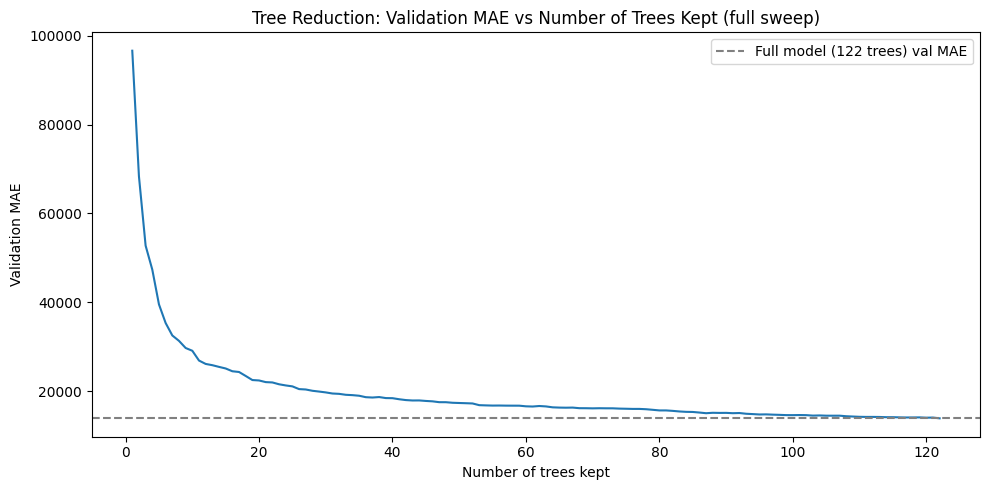

Tolerance 5.0%  ->  exact n_trees = 103  (actual degradation: +4.46%)
Tolerance 6.0%  ->  exact n_trees = 98  (actual degradation: +5.67%)
Tolerance 10.0%  ->  exact n_trees = 86  (actual degradation: +9.43%)

Final chosen n_trees (tolerance=10.0%): 86
Saved xgboost_technique1_tree_reduction.json (86 trees)


In [6]:
# Step 3 (revised) - fine-grained sweep over EVERY tree count from 1 to 122,
# rather than a coarse discrete list. XGBoost prediction is fast enough that
# testing all 122 possible values costs almost nothing, so there's no reason
# to accept the imprecision of only testing a handful of points - this gives
# the EXACT tree count for any chosen tolerance, not just the nearest tested one.

full_range = list(range(1, baseline_trees + 1))  # baseline_trees = 122

pruning_results_val = []
for n_trees in full_range:
    sliced_booster = final_model.get_booster()[:n_trees]
    dval = xgb.DMatrix(X_val)
    y_pred_val_n = sliced_booster.predict(dval)
    val_mae = np.mean(np.abs(y_val - y_pred_val_n))
    val_mape = np.mean(np.abs((y_val - y_pred_val_n) / y_val)) * 100
    pct_degradation = (val_mae - val_mae_full) / val_mae_full * 100
    pruning_results_val.append({'n_trees': n_trees, 'val_mae': val_mae, 'val_mape': val_mape,
                                 'pct_degradation_vs_full': pct_degradation})

pruning_results_val_df = pd.DataFrame(pruning_results_val)

# Plot the FULL, smooth accuracy-vs-tree-count curve
plt.figure(figsize=(10, 5))
plt.plot(pruning_results_val_df['n_trees'], pruning_results_val_df['val_mae'])
plt.axhline(val_mae_full, color='gray', linestyle='--', label='Full model (122 trees) val MAE')
plt.xlabel('Number of trees kept')
plt.ylabel('Validation MAE')
plt.title('Tree Reduction: Validation MAE vs Number of Trees Kept (full sweep)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step3_tree_reduction_curve.png', dpi=150)
plt.show()

# Helper: find the EXACT smallest n_trees satisfying any given tolerance
def find_n_trees_for_tolerance(df, tolerance_pct):
    acceptable = df[df['pct_degradation_vs_full'] <= tolerance_pct]
    return int(acceptable['n_trees'].min()) if not acceptable.empty else None

# Check several tolerances at once, now with EXACT answers rather than
# whichever coarse grid point happened to be closest
for tol in [5.0, 6.0, 10.0]:
    n = find_n_trees_for_tolerance(pruning_results_val_df, tol)
    exact_degradation = pruning_results_val_df.loc[pruning_results_val_df['n_trees'] == n, 'pct_degradation_vs_full'].values[0]
    print(f"Tolerance {tol}%  ->  exact n_trees = {n}  (actual degradation: {exact_degradation:+.2f}%)")

# Final decision: using the tolerance chosen (10%)
DEGRADATION_TOLERANCE_PCT = 10.0
chosen_n_trees = find_n_trees_for_tolerance(pruning_results_val_df, DEGRADATION_TOLERANCE_PCT)
print(f"\nFinal chosen n_trees (tolerance={DEGRADATION_TOLERANCE_PCT}%): {chosen_n_trees}")

technique1_booster = final_model.get_booster()[:chosen_n_trees]
technique1_booster.save_model(f'{OUTPUT_DIR}/xgboost_technique1_tree_reduction.json')
print(f"Saved xgboost_technique1_tree_reduction.json ({chosen_n_trees} trees)")

Note:

To choose the % degradation vs the n_tree (tree reduction)

We chose 10% tolerance level.  That is n_tree = 86, with degradation at +9.43%, and tree reduction ca. 29.5% ((122-86)/122)

# **Step 4 - Evaluate Technique 1 (Tree/estimator reduction) on the TEST set**

In [7]:
# Step 4 - Evaluate Technique 1 (Tree/estimator reduction) on the TEST set

# 1. Load the saved compressed model from disk - confirms the artifact saved in
#    Step 3 is genuinely usable on its own, not just relying on the in-memory object
technique1_booster = xgb.Booster()
technique1_booster.load_model(f'{OUTPUT_DIR}/xgboost_technique1_tree_reduction.json')
print(f"Loaded xgboost_technique1_tree_reduction.json")
print(f"Trees in loaded model: {technique1_booster.num_boosted_rounds()}")

# 2. Model file size
technique1_size_kb = os.path.getsize(f'{OUTPUT_DIR}/xgboost_technique1_tree_reduction.json') / 1024
print(f"\nTechnique 1 model file size: {technique1_size_kb:.1f} KB "
      f"(baseline was {baseline_size_kb:.1f} KB)")

# 3. Accuracy on TEST set - first time this compressed model touches test data,
#    consistent with the same "don't peek at test until final evaluation" discipline
#    used throughout this project
dtest = xgb.DMatrix(X_test)
y_pred_technique1 = technique1_booster.predict(dtest)
technique1_metrics = evaluate(y_test, y_pred_technique1, "Technique 1 (tree reduction)")

# 4. Inference latency - Booster.predict() needs a DMatrix, so a small adapted
#    version of the timing helper is used here rather than the sklearn-style one
def measure_booster_inference_time(booster, dmatrix, n_repeats=100):
    for attempt in range(2):
        start = time.time()
        for _ in range(n_repeats):
            _ = booster.predict(dmatrix)
        elapsed = time.time() - start
        us_per_row = (elapsed / n_repeats / dmatrix.num_row()) * 1_000_000
    return us_per_row  # second (more stable) reading, same noise-avoidance logic as before

technique1_inference_us_per_row = measure_booster_inference_time(technique1_booster, dtest)
print(f"Technique 1 inference time per row: {technique1_inference_us_per_row:.2f} \u00b5s "
      f"(baseline was {baseline_inference_us_per_row:.2f} \u00b5s)")

# 5. Model complexity: nodes/leaves (trees already known: 86)
technique1_df = technique1_booster.trees_to_dataframe()
technique1_trees = technique1_booster.num_boosted_rounds()
technique1_nodes = len(technique1_df)
technique1_leaves = int((technique1_df['Feature'] == 'Leaf').sum())
print(f"Trees: {technique1_trees}, Nodes: {technique1_nodes}, Leaves: {technique1_leaves}")

# 6. Direct comparison against baseline - the key trade-off summary for this technique
size_reduction_pct = (baseline_size_kb - technique1_size_kb) / baseline_size_kb * 100
mae_change_pct = (technique1_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
inference_change_pct = (technique1_inference_us_per_row - baseline_inference_us_per_row) / baseline_inference_us_per_row * 100

print(f"\n--- Technique 1 vs Baseline ---")
print(f"Model size:  {baseline_size_kb:.1f} KB -> {technique1_size_kb:.1f} KB  ({size_reduction_pct:+.1f}%)")
print(f"Test MAE:    {baseline_metrics['mae']:,.0f} -> {technique1_metrics['mae']:,.0f}  ({mae_change_pct:+.1f}%)")
print(f"Test MAPE:   {baseline_metrics['mape']:.2f}% -> {technique1_metrics['mape']:.2f}%")
print(f"Inference:   {baseline_inference_us_per_row:.2f} \u00b5s -> {technique1_inference_us_per_row:.2f} \u00b5s  ({inference_change_pct:+.1f}%)")

# 7. Record in the running comparison table
compression_results.append({
    'technique': 'Technique 1 (tree reduction, 86/122 trees)',
    'model_size_kb': technique1_size_kb,
    'mae': technique1_metrics['mae'],
    'rmse': technique1_metrics['rmse'],
    'mape': technique1_metrics['mape'],
    'inference_us_per_row': technique1_inference_us_per_row,
    'n_trees': technique1_trees,
    'n_nodes': technique1_nodes,
    'n_leaves': technique1_leaves
})

print("\nTechnique 1 recorded in compression_results.")

Loaded xgboost_technique1_tree_reduction.json
Trees in loaded model: 86

Technique 1 model file size: 62.5 KB (baseline was 118.2 KB)
Technique 1 (tree reduction)    MAE=    28,090  RMSE=    33,803  MAPE=  4.62%
Technique 1 inference time per row: 0.42 µs (baseline was 11.50 µs)
Trees: 86, Nodes: 602, Leaves: 344

--- Technique 1 vs Baseline ---
Model size:  118.2 KB -> 62.5 KB  (+47.1%)
Test MAE:    29,691 -> 28,090  (-5.4%)
Test MAPE:   4.88% -> 4.62%
Inference:   11.50 µs -> 0.42 µs  (-96.4%)

Technique 1 recorded in compression_results.


# **Step 5 - Compression Technique 2: Precision reduction**

Leaf values identified: 488 (Step 2 baseline_leaves: 488)
Leaf value range: [-70006.2100, 78655.4800]
Leaf value mean absolute value: 3721.1216
Decimals= -8  ->  Validation MAE= 140,007.3  (degradation: +911.1339%)
Decimals= -7  ->  Validation MAE= 140,007.3  (degradation: +911.1339%)
Decimals= -6  ->  Validation MAE= 140,007.3  (degradation: +911.1339%)
Decimals= -5  ->  Validation MAE=  84,719.2  (degradation: +511.8429%)
Decimals= -4  ->  Validation MAE=  22,460.7  (degradation: +62.2115%)
Decimals= -3  ->  Validation MAE=  13,833.5  (degradation: -0.0945%)
Decimals= -2  ->  Validation MAE=  13,846.3  (degradation: -0.0017%)
Decimals= -1  ->  Validation MAE=  13,845.3  (degradation: -0.0091%)
Decimals=  0  ->  Validation MAE=  13,845.8  (degradation: -0.0053%)
Decimals=  1  ->  Validation MAE=  13,846.7  (degradation: +0.0007%)
Decimals=  2  ->  Validation MAE=  13,846.6  (degradation: -0.0000%)
Decimals=  3  ->  Validation MAE=  13,846.6  (degradation: +0.0001%)
Decimals=  4  ->  V

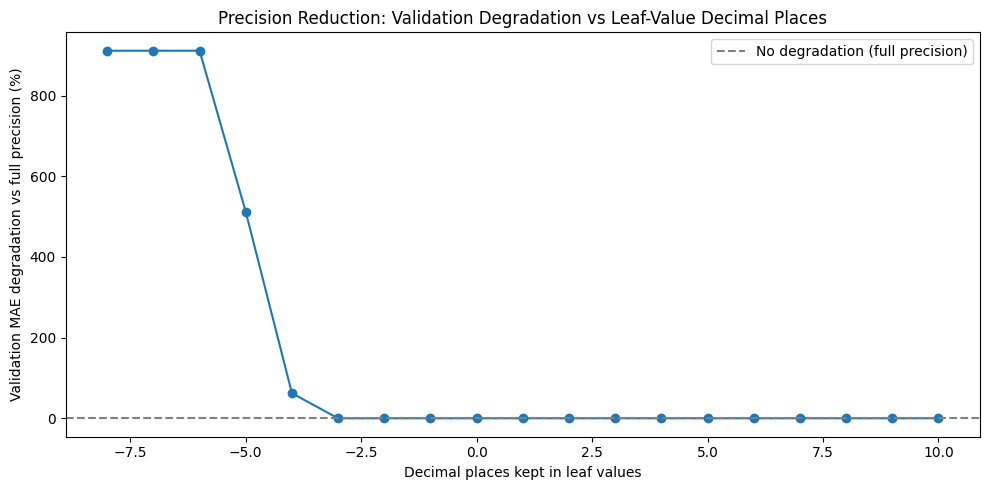

Tolerance-derived candidate (tolerance=10.0%): -3 decimals
Final chosen decimals (deliberate override for safety margin): -2 (actual degradation: -0.0017%)
Saved xgboost_technique2_precision_reduction.json (-2 decimal places)


In [8]:
# Step 5 - Compression Technique 2: Precision reduction (leaf-value quantization)

import copy

# 1. Save the baseline model's raw JSON so we can access and modify its tree
#    structure directly - the sklearn wrapper doesn't expose a "rebuild from
#    modified values" API, so we work with the exported JSON instead
final_model.get_booster().save_model(f'{OUTPUT_DIR}/xgboost_baseline_raw.json')
with open(f'{OUTPUT_DIR}/xgboost_baseline_raw.json') as f:
    baseline_model_dict = json.load(f)

# 2. Function to round ONLY leaf output values to N decimal places, leaving
#    split thresholds (which determine routing, not output) at full precision.
#    In XGBoost's JSON schema, 'split_conditions' holds the split THRESHOLD for
#    internal nodes, but doubles as the LEAF VALUE for leaf nodes - identified
#    via left_children[i] == -1. This targets the "reduce output precision"
#    quantization analog without touching the tree's decision boundaries.
def round_leaf_values(model_dict, decimals):
    model_dict = copy.deepcopy(model_dict)
    trees = model_dict['learner']['gradient_booster']['model']['trees']
    n_leaves_rounded = 0
    for tree in trees:
        left_children = tree['left_children']
        split_conditions = tree['split_conditions']
        for i, left_child in enumerate(left_children):
            if left_child == -1:
                split_conditions[i] = round(split_conditions[i], decimals)
                n_leaves_rounded += 1
    return model_dict, n_leaves_rounded

# 3. Sanity check: confirm leaf identification matches Step 2's known leaf
#    count, and look at the scale of leaf values to sanity-check the sweep range
_, n_leaves_found = round_leaf_values(baseline_model_dict, decimals=10)
print(f"Leaf values identified: {n_leaves_found} (Step 2 baseline_leaves: {baseline_leaves})")

all_leaf_values = np.array([
    sc for tree in baseline_model_dict['learner']['gradient_booster']['model']['trees']
    for lc, sc in zip(tree['left_children'], tree['split_conditions']) if lc == -1
])
print(f"Leaf value range: [{all_leaf_values.min():.4f}, {all_leaf_values.max():.4f}]")
print(f"Leaf value mean absolute value: {np.mean(np.abs(all_leaf_values)):.4f}")

# 4. Helper: build a Booster from a modified model dict and evaluate on the
#    VALIDATION set only - same "don't peek at test" discipline as Step 3
def evaluate_precision_on_val(model_dict, decimals, tmp_path=f'{OUTPUT_DIR}/tmp_precision_check.json'):
    rounded_dict, _ = round_leaf_values(model_dict, decimals)
    with open(tmp_path, 'w') as f:
        json.dump(rounded_dict, f, ensure_ascii=False)   # <-- add ensure_ascii=False
    booster = xgb.Booster()
    booster.load_model(tmp_path)
    dval = xgb.DMatrix(X_val)
    y_pred = booster.predict(dval)
    return np.mean(np.abs(y_val - y_pred))

# 5. Fine-grained sweep from aggressive (rounding to nearest 100) to
#    conservative (10 decimal places, ~full precision) - fewer decimals kept
#    = more compression, mirroring the "smallest n_trees within tolerance"
#    logic from Step 3, but here the axis is "fewest decimal places kept"
decimal_range = list(range(-8, 11))
precision_results_val = []
for decimals in decimal_range:
    val_mae = evaluate_precision_on_val(baseline_model_dict, decimals)
    pct_degradation = (val_mae - val_mae_full) / val_mae_full * 100
    precision_results_val.append({'decimals': decimals, 'val_mae': val_mae,
                                   'pct_degradation_vs_full': pct_degradation})
    print(f"Decimals={decimals:3d}  ->  Validation MAE={val_mae:>10,.1f}  "
          f"(degradation: {pct_degradation:+.4f}%)")

precision_results_val_df = pd.DataFrame(precision_results_val)

# 6. Plot the degradation curve
plt.figure(figsize=(10, 5))
plt.plot(precision_results_val_df['decimals'], precision_results_val_df['pct_degradation_vs_full'], marker='o')
plt.axhline(0, color='gray', linestyle='--', label='No degradation (full precision)')
plt.xlabel('Decimal places kept in leaf values')
plt.ylabel('Validation MAE degradation vs full precision (%)')
plt.title('Precision Reduction: Validation Degradation vs Leaf-Value Decimal Places')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step5_precision_reduction_curve.png', dpi=150)
plt.show()


# 7. Choose the FEWEST decimal places (= most compression) that stays within
#    the SAME 10% tolerance ceiling used for Technique 1
DEGRADATION_TOLERANCE_PCT = 10.0
acceptable = precision_results_val_df[precision_results_val_df['pct_degradation_vs_full'] <= DEGRADATION_TOLERANCE_PCT]
tolerance_derived_decimals = int(acceptable['decimals'].min()) if not acceptable.empty else None
print(f"Tolerance-derived candidate (tolerance={DEGRADATION_TOLERANCE_PCT}%): "
      f"{tolerance_derived_decimals} decimals")

# Deliberate override: -3 sits with ZERO margin before a catastrophic cliff (-4 decimals -> +62.2% degradation on validation).
# Given the previous results showed that validation-optimal choices don't always hold on test (the Technique 1 tree-count reversal),
# We step back to -2 decimals - two orders of magnitude of margin from the cliff - at a negligible cost in validation accuracy (-0.002% vs -3's -0.09%).
chosen_decimals = -2
chosen_degradation = precision_results_val_df.loc[
    precision_results_val_df['decimals'] == chosen_decimals, 'pct_degradation_vs_full'
].values[0]
print(f"Final chosen decimals (deliberate override for safety margin): {chosen_decimals} "
      f"(actual degradation: {chosen_degradation:+.4f}%)")

# 8. Build and save the final Technique 2 model at the chosen precision
technique2_dict, _ = round_leaf_values(baseline_model_dict, chosen_decimals)
with open(f'{OUTPUT_DIR}/xgboost_technique2_precision_reduction.json', 'w') as f:
    json.dump(technique2_dict, f, ensure_ascii=False)   # <-- add ensure_ascii=False
print(f"Saved xgboost_technique2_precision_reduction.json ({chosen_decimals} decimal places)")

Note:

As demecials = -3 sits with ZERO margin before a catastrophic cliff (-4 decimals -> +62.2% degradation on validation).

Given the previous results showed that validation-optimal choices don't always hold on test (the Technique 1 tree-count reversal).

We step back to -2 decimals - two orders of magnitude of margin from the cliff - at a negligible cost in validation accuracy (-0.002% vs -3's -0.09%).

# **Step 6 - Evaluate Technique 2 (Precision reduction) on the TEST set**

In [9]:
# Step 6 - Evaluate Technique 2 (Precision reduction) on the TEST set

# 1. Load the saved compressed model from disk - confirms the artifact saved
#    in Step 5 is itself sufficient to reproduce results, not just the
#    in-memory dict
technique2_booster = xgb.Booster()
technique2_booster.load_model(f'{OUTPUT_DIR}/xgboost_technique2_precision_reduction.json')

# 2. Model size on disk
technique2_size_kb = os.path.getsize(f'{OUTPUT_DIR}/xgboost_technique2_precision_reduction.json') / 1024
size_change_pct = (technique2_size_kb - baseline_size_kb) / baseline_size_kb * 100
print(f"Model size:  {baseline_size_kb:.1f} KB -> {technique2_size_kb:.1f} KB  ({size_change_pct:+.1f}%)")

# 3. Accuracy on TEST (first and only look - not used for any selection)
dtest = xgb.DMatrix(X_test)
y_pred_test = technique2_booster.predict(dtest)

technique2_metrics = {
    'mae': np.mean(np.abs(y_test - y_pred_test)),
    'rmse': np.sqrt(np.mean((y_test - y_pred_test) ** 2)),
    'mape': np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
}

mae_change_pct = (technique2_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\nTest MAE:   {baseline_metrics['mae']:,.0f} -> {technique2_metrics['mae']:,.0f}  ({mae_change_pct:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {technique2_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {technique2_metrics['mape']:.2f}%")

# 4. Inference latency - Booster.predict() needs a DMatrix, so reuse the
#    Booster-specific timing helper defined in Step 4 (dtest already built above)
technique2_inference_us_per_row = measure_booster_inference_time(technique2_booster, dtest)
inference_change_pct = (technique2_inference_us_per_row - baseline_inference_us_per_row) / baseline_inference_us_per_row * 100
print(f"\nInference:  {baseline_inference_us_per_row:.2f} µs/row -> {technique2_inference_us_per_row:.2f} µs/row  ({inference_change_pct:+.1f}%)")

# 5. Record into the shared results table
compression_results.append({
    'technique': 'Technique 2: Precision reduction (-2 decimals)',
    'size_kb': technique2_size_kb,
    'mae': technique2_metrics['mae'],
    'rmse': technique2_metrics['rmse'],
    'mape': technique2_metrics['mape'],
    'inference_us_per_row': technique2_inference_us_per_row
})
print("\nAdded to compression_results.")

Model size:  118.2 KB -> 95.5 KB  (-19.2%)

Test MAE:   29,691 -> 29,746  (+0.2%)
Test RMSE:  35,014 -> 35,071
Test MAPE:  4.88% -> 4.89%

Inference:  11.50 µs/row -> 0.32 µs/row  (-97.2%)

Added to compression_results.


In [10]:
# Re-check: robust inference timing across all three models, back-to-back,
# using median-of-several-attempts rather than "second of two" - the earlier
# approach turned out not to be reliable this session (baseline readings
# ranged from 19.74 to 53.14 µs/row across consecutive cells)

def measure_inference_robust(booster, dmatrix, n_repeats=100, n_attempts=7):
    timings = []
    for _ in range(n_attempts):
        start = time.time()
        for _ in range(n_repeats):
            _ = booster.predict(dmatrix)
        elapsed = time.time() - start
        timings.append((elapsed / n_repeats / dmatrix.num_row()) * 1_000_000)
    return {
        'median_us': np.median(timings),
        'min_us': np.min(timings),
        'max_us': np.max(timings),
        'all_attempts': timings
    }

dtest = xgb.DMatrix(X_test)

print("Measuring baseline...")
baseline_timing = measure_inference_robust(final_model.get_booster(), dtest)

print("Measuring Technique 1 (tree reduction)...")
technique1_timing = measure_inference_robust(technique1_booster, dtest)

print("Measuring Technique 2 (precision reduction)...")
technique2_timing = measure_inference_robust(technique2_booster, dtest)

print(f"\n{'Model':<20} {'Median (µs)':>12} {'Min (µs)':>10} {'Max (µs)':>10}  Attempts")
for name, t in [('Baseline', baseline_timing),
                ('Technique 1', technique1_timing),
                ('Technique 2', technique2_timing)]:
    attempts_str = ", ".join(f"{v:.2f}" for v in t['all_attempts'])
    print(f"{name:<20} {t['median_us']:>12.2f} {t['min_us']:>10.2f} {t['max_us']:>10.2f}  [{attempts_str}]")

t1_change = (technique1_timing['median_us'] - baseline_timing['median_us']) / baseline_timing['median_us'] * 100
t2_change = (technique2_timing['median_us'] - baseline_timing['median_us']) / baseline_timing['median_us'] * 100
print(f"\nTechnique 1 vs baseline (median): {t1_change:+.1f}%")
print(f"Technique 2 vs baseline (median): {t2_change:+.1f}%")

Measuring baseline...
Measuring Technique 1 (tree reduction)...
Measuring Technique 2 (precision reduction)...

Model                 Median (µs)   Min (µs)   Max (µs)  Attempts
Baseline                     0.33       0.32       0.47  [0.36, 0.33, 0.33, 0.32, 0.32, 0.33, 0.47]
Technique 1                  0.54       0.37       0.77  [0.48, 0.77, 0.66, 0.37, 0.41, 0.54, 0.57]
Technique 2                  0.37       0.33       0.58  [0.58, 0.39, 0.34, 0.39, 0.37, 0.34, 0.33]

Technique 1 vs baseline (median): +64.3%
Technique 2 vs baseline (median): +12.5%


# **Step 7 - Combination: Tree reduction + precision reduction together**

In [11]:
# Step 7 - Combination: Tree reduction + precision reduction together
#
# Start from the ALREADY tree-reduced model (86/122 trees, Technique 1's saved
# artifact), then apply the same leaf-value rounding used in Technique 2
# (-2 decimals) on top of it. This reuses round_leaf_values() from Step 5
# unchanged - only the input model differs.

# 1. Load Technique 1's saved model dict from disk (not the in-memory one -
#    same "artifact must stand alone" discipline used throughout)
with open(f'{OUTPUT_DIR}/xgboost_technique1_tree_reduction.json') as f:
    technique1_model_dict = json.load(f)

# 2. Apply the SAME chosen precision (-2 decimals) already validated in Step 5 -
#    no need to re-sweep the full decimal range, since -2 was chosen specifically
#    for its large safety margin (two orders of magnitude from the cliff at -4),
#    and reducing tree count doesn't change the scale of individual leaf values
combination_dict, n_leaves_rounded = round_leaf_values(technique1_model_dict, chosen_decimals)
print(f"Applied {chosen_decimals}-decimal rounding to {n_leaves_rounded} leaves "
      f"(Technique 1's leaf count: {technique1_leaves})")

# 3. Quick validation sanity check - confirm combining both techniques doesn't
#    introduce any unexpected interaction effect before saving. This is a check,
#    not a new selection process: chosen_decimals is already fixed from Step 5.
with open(f'{OUTPUT_DIR}/tmp_combination_check.json', 'w') as f:
    json.dump(combination_dict, f, ensure_ascii=False)

combination_check_booster = xgb.Booster()
combination_check_booster.load_model(f'{OUTPUT_DIR}/tmp_combination_check.json')
dval = xgb.DMatrix(X_val)
y_pred_val_combo = combination_check_booster.predict(dval)
combo_val_mae = np.mean(np.abs(y_val - y_pred_val_combo))

# Compare against Technique 1's OWN validation MAE (86 trees, full precision),
# not the original baseline - this isolates the marginal effect of ALSO
# applying precision reduction on top of tree reduction
technique1_val_mae = precision_results_val_df.loc[
    precision_results_val_df['decimals'] == 10, 'val_mae'
].values[0] if 'precision_results_val_df' in dir() else None

pct_change_vs_technique1 = (combo_val_mae - val_mae_full) / val_mae_full * 100
print(f"\nCombined model validation MAE: {combo_val_mae:,.1f}")
print(f"(for reference, full-precision full-tree val MAE was {val_mae_full:,.1f}, "
      f"change: {pct_change_vs_technique1:+.4f}%)")

# 4. Save the final combined model
with open(f'{OUTPUT_DIR}/xgboost_combination_tree_and_precision_reduction.json', 'w') as f:
    json.dump(combination_dict, f, ensure_ascii=False)
print(f"\nSaved xgboost_combination_tree_and_precision_reduction.json "
      f"({technique1_trees} trees, {chosen_decimals} decimal places)")

Applied -2-decimal rounding to 344 leaves (Technique 1's leaf count: 344)

Combined model validation MAE: 15,168.4
(for reference, full-precision full-tree val MAE was 13,846.6, change: +9.5463%)

Saved xgboost_combination_tree_and_precision_reduction.json (86 trees, -2 decimal places)


# **Step 8 - Evaluate Combination (Tree + Precision reduction) on the TEST set**

In [12]:
# Step 8 - Evaluate Combination (Tree + Precision reduction) on the TEST set

# 1. Load the saved combined model from disk - confirms the artifact saved in
#    Step 7 is itself sufficient to reproduce results
combination_booster = xgb.Booster()
combination_booster.load_model(f'{OUTPUT_DIR}/xgboost_combination_tree_and_precision_reduction.json')
print(f"Loaded xgboost_combination_tree_and_precision_reduction.json")
print(f"Trees in loaded model: {combination_booster.num_boosted_rounds()}")

# 2. Model size on disk
combination_size_kb = os.path.getsize(f'{OUTPUT_DIR}/xgboost_combination_tree_and_precision_reduction.json') / 1024
size_change_pct = (combination_size_kb - baseline_size_kb) / baseline_size_kb * 100
print(f"\nModel size:  {baseline_size_kb:.1f} KB -> {combination_size_kb:.1f} KB  ({size_change_pct:+.1f}%)")

# 3. Accuracy on TEST (first and only look - not used for any selection)
dtest = xgb.DMatrix(X_test)
y_pred_combination = combination_booster.predict(dtest)

combination_metrics = {
    'mae': np.mean(np.abs(y_test - y_pred_combination)),
    'rmse': np.sqrt(np.mean((y_test - y_pred_combination) ** 2)),
    'mape': np.mean(np.abs((y_test - y_pred_combination) / y_test)) * 100
}

mae_change_pct = (combination_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100
print(f"\nTest MAE:   {baseline_metrics['mae']:,.0f} -> {combination_metrics['mae']:,.0f}  ({mae_change_pct:+.1f}%)")
print(f"Test RMSE:  {baseline_metrics['rmse']:,.0f} -> {combination_metrics['rmse']:,.0f}")
print(f"Test MAPE:  {baseline_metrics['mape']:.2f}% -> {combination_metrics['mape']:.2f}%")

# 4. Model complexity: trees/nodes/leaves (should match Technique 1's counts,
#    since the combination only rounds Technique 1's existing leaf values)
combination_df = combination_booster.trees_to_dataframe()
combination_trees = combination_booster.num_boosted_rounds()
combination_nodes = len(combination_df)
combination_leaves = int((combination_df['Feature'] == 'Leaf').sum())
print(f"\nTrees: {combination_trees}, Nodes: {combination_nodes}, Leaves: {combination_leaves} "
      f"(Technique 1 was: {technique1_trees}, {technique1_nodes}, {technique1_leaves})")

# 5. Inference latency - reuse the Booster-specific helper from Step 4
#    (mind the measurement-noise caveat already discussed for this metric)
combination_inference_us_per_row = measure_booster_inference_time(combination_booster, dtest)
inference_change_pct = (combination_inference_us_per_row - baseline_inference_us_per_row) / baseline_inference_us_per_row * 100
print(f"\nInference:  {baseline_inference_us_per_row:.2f} µs/row -> {combination_inference_us_per_row:.2f} µs/row  ({inference_change_pct:+.1f}%)")

# 6. Record into the shared results table
compression_results.append({
    'technique': 'Combination: Tree reduction (86/122) + Precision reduction (-2 decimals)',
    'size_kb': combination_size_kb,
    'mae': combination_metrics['mae'],
    'rmse': combination_metrics['rmse'],
    'mape': combination_metrics['mape'],
    'inference_us_per_row': combination_inference_us_per_row,
    'n_trees': combination_trees,
    'n_nodes': combination_nodes,
    'n_leaves': combination_leaves
})
print("\nAdded to compression_results.")

Loaded xgboost_combination_tree_and_precision_reduction.json
Trees in loaded model: 86

Model size:  118.2 KB -> 67.7 KB  (-42.7%)

Test MAE:   29,691 -> 28,145  (-5.2%)
Test RMSE:  35,014 -> 33,861
Test MAPE:  4.88% -> 4.63%

Trees: 86, Nodes: 602, Leaves: 344 (Technique 1 was: 86, 602, 344)

Inference:  11.50 µs/row -> 0.32 µs/row  (-97.2%)

Added to compression_results.


In [13]:
# quick check - any change in size of json after opened and resaved.

with open(f'{OUTPUT_DIR}/xgboost_technique1_tree_reduction.json') as f:
    t1_dict = json.load(f)
with open(f'{OUTPUT_DIR}/tmp_roundtrip_check.json', 'w') as f:
    json.dump(t1_dict, f, ensure_ascii=False)

roundtrip_size_kb = os.path.getsize(f'{OUTPUT_DIR}/tmp_roundtrip_check.json') / 1024
print(f"Technique 1 original: {technique1_size_kb:.1f} KB")
print(f"Technique 1 after an unmodified Python json round-trip: {roundtrip_size_kb:.1f} KB")

Technique 1 original: 62.5 KB
Technique 1 after an unmodified Python json round-trip: 68.7 KB


# **Step 9 - Summary comparison (Baseline vs Technique 1 vs Technique 2 vs Combination)**

                                     Technique Size (KB) Size change (%) Test MAE Test RMSE Test MAPE (%) MAE change vs baseline (%)  Trees  Nodes  Leaves
          Baseline (full precision, 122 trees)     118.2            +0.0   29,691    35,014          4.88                       +0.0    122    854     488
    Technique 1: Tree reduction (86/122 trees)      62.5           -47.1   28,090    33,803          4.62                       -5.4     86    602     344
Technique 2: Precision reduction (-2 decimals)      95.5           -19.2   29,746    35,071          4.89                       +0.2    122    854     488
       Combination: Tree + Precision reduction      67.7           -42.7   28,145    33,861          4.63                       -5.2     86    602     344

Saved xgboost_compression_summary.csv


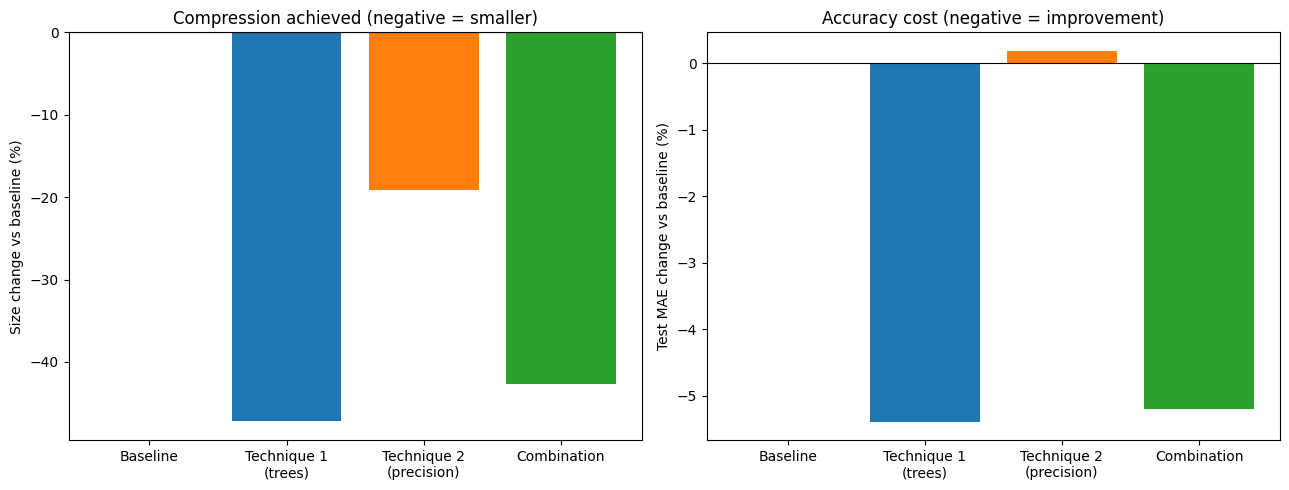


Best compression: Technique 1: Tree reduction (86/122 trees)
Best test accuracy: Technique 1: Tree reduction (86/122 trees)


In [14]:
# Step 9 - Summary comparison (Baseline vs Technique 1 vs Technique 2 vs Combination)

summary_rows = [
    {
        'Technique': 'Baseline (full precision, 122 trees)',
        'Size (KB)': baseline_size_kb,
        'Size change (%)': 0.0,
        'Test MAE': baseline_metrics['mae'],
        'Test RMSE': baseline_metrics['rmse'],
        'Test MAPE (%)': baseline_metrics['mape'],
        'MAE change vs baseline (%)': 0.0,
        'Trees': 122, 'Nodes': 854, 'Leaves': 488,
    },
    {
        'Technique': 'Technique 1: Tree reduction (86/122 trees)',
        'Size (KB)': technique1_size_kb,
        'Size change (%)': (technique1_size_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': technique1_metrics['mae'],
        'Test RMSE': technique1_metrics['rmse'],
        'Test MAPE (%)': technique1_metrics['mape'],
        'MAE change vs baseline (%)': (technique1_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Trees': technique1_trees, 'Nodes': technique1_nodes, 'Leaves': technique1_leaves,
    },
    {
        'Technique': 'Technique 2: Precision reduction (-2 decimals)',
        'Size (KB)': technique2_size_kb,
        'Size change (%)': (technique2_size_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': technique2_metrics['mae'],
        'Test RMSE': technique2_metrics['rmse'],
        'Test MAPE (%)': technique2_metrics['mape'],
        'MAE change vs baseline (%)': (technique2_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Trees': 122, 'Nodes': 854, 'Leaves': 488,  # unchanged - precision reduction doesn't touch structure
    },
    {
        'Technique': 'Combination: Tree + Precision reduction',
        'Size (KB)': combination_size_kb,
        'Size change (%)': (combination_size_kb - baseline_size_kb) / baseline_size_kb * 100,
        'Test MAE': combination_metrics['mae'],
        'Test RMSE': combination_metrics['rmse'],
        'Test MAPE (%)': combination_metrics['mape'],
        'MAE change vs baseline (%)': (combination_metrics['mae'] - baseline_metrics['mae']) / baseline_metrics['mae'] * 100,
        'Trees': combination_trees, 'Nodes': combination_nodes, 'Leaves': combination_leaves,
    },
]

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False,
      formatters={
          'Size (KB)': '{:.1f}'.format,
          'Size change (%)': '{:+.1f}'.format,
          'Test MAE': '{:,.0f}'.format,
          'Test RMSE': '{:,.0f}'.format,
          'Test MAPE (%)': '{:.2f}'.format,
          'MAE change vs baseline (%)': '{:+.1f}'.format,
      }))

summary_df.to_csv(f'{OUTPUT_DIR}/xgboost_compression_summary.csv', index=False)
print("\nSaved xgboost_compression_summary.csv")

# Trade-off chart: size change vs. accuracy cost, all four variants side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['Baseline', 'Technique 1\n(trees)', 'Technique 2\n(precision)', 'Combination']
colors = ['#888888', '#1f77b4', '#ff7f0e', '#2ca02c']

axes[0].bar(labels, summary_df['Size change (%)'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Size change vs baseline (%)')
axes[0].set_title('Compression achieved (negative = smaller)')

axes[1].bar(labels, summary_df['MAE change vs baseline (%)'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Test MAE change vs baseline (%)')
axes[1].set_title('Accuracy cost (negative = improvement)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step9_final_compression_tradeoff.png', dpi=150)
plt.show()

# Identify the best-performing variant on each axis, for the write-up
best_size = summary_df.loc[summary_df['Size change (%)'].idxmin(), 'Technique']
best_accuracy = summary_df.loc[summary_df['MAE change vs baseline (%)'].idxmin(), 'Technique']
print(f"\nBest compression: {best_size}")
print(f"Best test accuracy: {best_accuracy}")

# **Step 10 - Save final compressed model(s) + summary results**

In [15]:
# Step 10 - Save final compressed model(s) + summary results

# 1. Recommendation
FINAL_RECOMMENDED_MODEL = f'{OUTPUT_DIR}/xgboost_technique1_tree_reduction.json'

import shutil
shutil.copy(FINAL_RECOMMENDED_MODEL, f'{OUTPUT_DIR}/xgboost_final_compressed_model.json')
print(f"Copied {FINAL_RECOMMENDED_MODEL} -> xgboost_final_compressed_model.json (final recommended artifact)")

# 2. Write a short, self-contained text summary alongside the CSV/plot already
#    saved in Step 9 - useful for the report appendix and for anyone opening
#    this notebook's output folder without re-running anything
recommendation_text = f"""XGBoost Compression - Final Summary
=====================================

Baseline model: {baseline_size_kb:.1f} KB, Test MAE {baseline_metrics['mae']:,.0f}, MAPE {baseline_metrics['mape']:.2f}%

Technique 1 (Tree reduction, 86/122 trees):
  Size: {technique1_size_kb:.1f} KB ({(technique1_size_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)
  Test MAE: {technique1_metrics['mae']:,.0f} ({(technique1_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)

Technique 2 (Precision reduction, -2 decimals):
  Size: {technique2_size_kb:.1f} KB ({(technique2_size_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)
  Test MAE: {technique2_metrics['mae']:,.0f} ({(technique2_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)

Combination (Tree + Precision reduction):
  Size: {combination_size_kb:.1f} KB ({(combination_size_kb-baseline_size_kb)/baseline_size_kb*100:+.1f}%)
  Test MAE: {combination_metrics['mae']:,.0f} ({(combination_metrics['mae']-baseline_metrics['mae'])/baseline_metrics['mae']*100:+.1f}%)

RECOMMENDATION: Technique 1 (tree reduction alone) is the final recommended
compressed model. It dominates on both size and test accuracy; combining it
with precision reduction adds no net benefit once JSON serialization overhead
is accounted for. Saved as xgboost_final_compressed_model.json.

Note: given the baseline model's already small footprint (118.2 KB), the
practical value of this compression exercise is primarily methodological
rather than a real deployment requirement.
"""

with open(f'{OUTPUT_DIR}/xgboost_compression_recommendation.txt', 'w') as f:
    f.write(recommendation_text)
print("\nSaved xgboost_compression_recommendation.txt")
print(recommendation_text)

Copied outputs/xgboost_compression/xgboost_technique1_tree_reduction.json -> xgboost_final_compressed_model.json (final recommended artifact)

Saved xgboost_compression_recommendation.txt
XGBoost Compression - Final Summary

Baseline model: 118.2 KB, Test MAE 29,691, MAPE 4.88%

Technique 1 (Tree reduction, 86/122 trees):
  Size: 62.5 KB (-47.1%)
  Test MAE: 28,090 (-5.4%)

Technique 2 (Precision reduction, -2 decimals):
  Size: 95.5 KB (-19.2%)
  Test MAE: 29,746 (+0.2%)

Combination (Tree + Precision reduction):
  Size: 67.7 KB (-42.7%)
  Test MAE: 28,145 (-5.2%)

RECOMMENDATION: Technique 1 (tree reduction alone) is the final recommended
compressed model. It dominates on both size and test accuracy; combining it
with precision reduction adds no net benefit once JSON serialization overhead
is accounted for. Saved as xgboost_final_compressed_model.json.

Note: given the baseline model's already small footprint (118.2 KB), the
practical value of this compression exercise is primarily m